In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
cols= ["flength",'fwidth','fsize','fconc','fconc1','fasym',"fm3long","fm3trans","faplha","fdist","fclass"]
df = pd .read_csv("magic04.data",names=cols)

In [4]:
df.head()

,flength,fwidth,fsize,fconc,fconc1,fasym,fm3long,fm3trans,faplha,fdist,fclass
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [5]:
df["fclass"].unique()
df["fclass"]= (df["fclass"]=='g').astype(int)

In [6]:
df

,flength,fwidth,fsize,fconc,fconc1,fasym,fm3long,fm3trans,faplha,fdist,fclass
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0


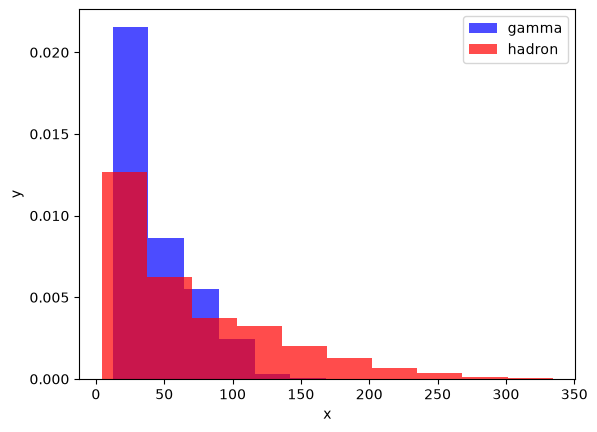

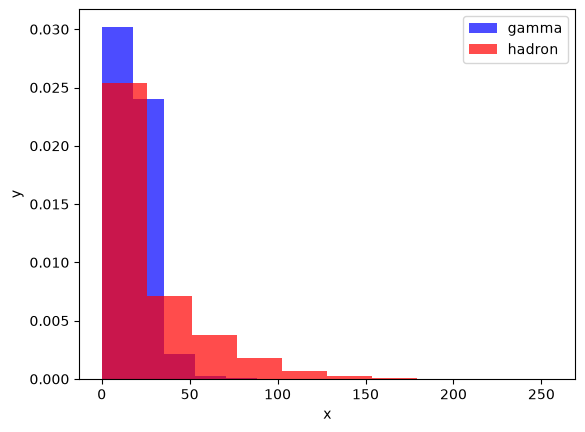

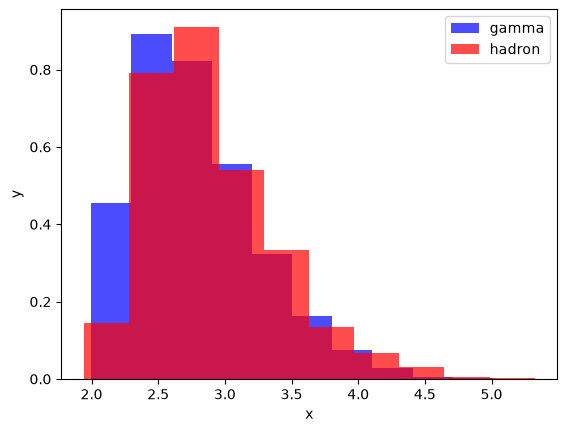

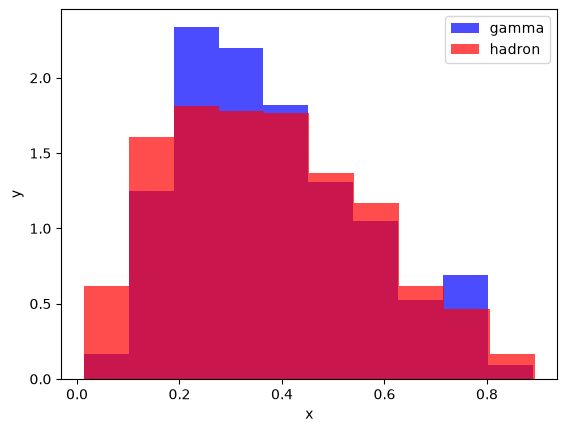

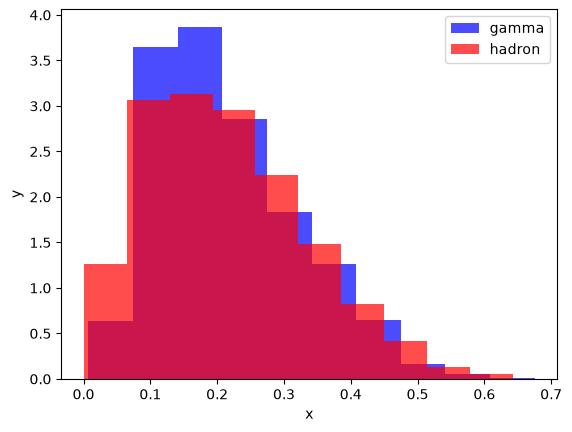

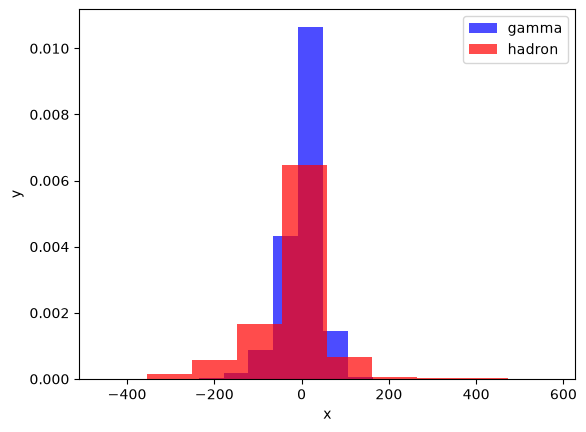

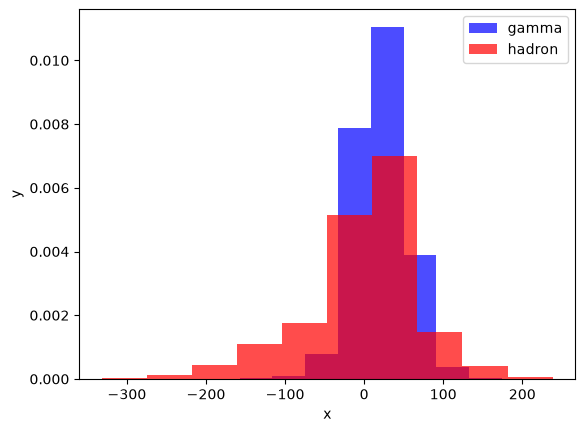

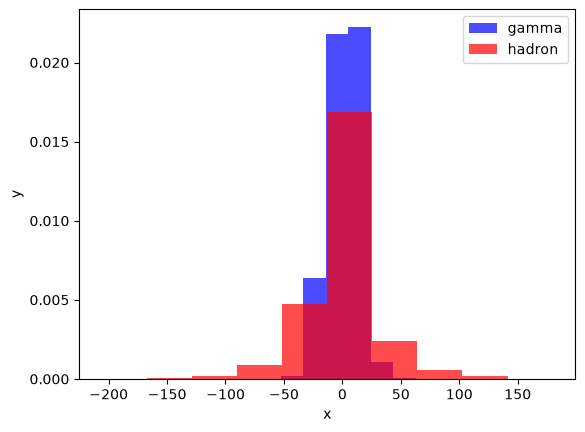

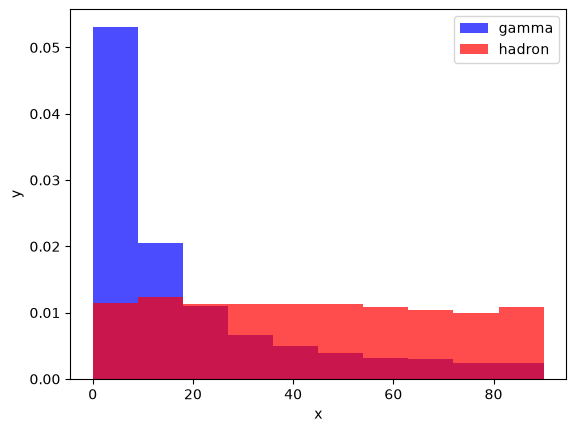

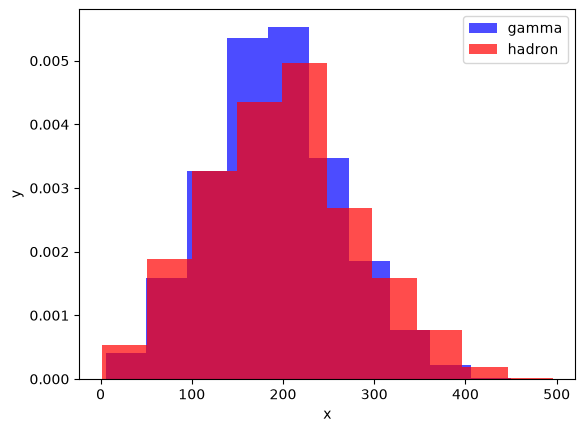

In [8]:
for label in cols[:-1]:
    plt.hist(df[df["fclass"]==1][label],color = "blue" , label ="gamma",alpha=0.7,density=True)
    plt.hist(df[df["fclass"]==0][label],color = "red" , label ="hadron",alpha=0.7,density=True)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test = df.iloc[int(0.8 * len(df)):]

In [10]:

x=df[df.columns[:-1]].values
y=df[df.columns[-1]].values
    

    

In [11]:
print(len(train[train["fclass"]==1]))
print(len(train[train["fclass"]==0]))

7409
4003


In [12]:
len(train)

11412

In [13]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xtrain,ytrain)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
y_pred = knn.predict(xtest)

In [17]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.59      0.68      1394
           1       0.80      0.92      0.85      2410

    accuracy                           0.80      3804
   macro avg       0.80      0.76      0.77      3804
weighted avg       0.80      0.80      0.79      3804



Native Bayes

In [18]:
from sklearn.naive_bayes import GaussianNB
n = GaussianNB()
n.fit(xtrain,ytrain)

,priors,None
,var_smoothing,1e-09


In [19]:
y_pred = n.predict(xtest)

In [20]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.39      0.51      1394
           1       0.72      0.92      0.81      2410

    accuracy                           0.73      3804
   macro avg       0.73      0.65      0.66      3804
weighted avg       0.73      0.73      0.70      3804



logistic regression

In [21]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(xtrain,ytrain)


c:\Users\ADMIN\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred=lg.predict(xtest)

In [24]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.60      0.68      1394
           1       0.80      0.90      0.85      2410

    accuracy                           0.79      3804
   macro avg       0.79      0.75      0.76      3804
weighted avg       0.79      0.79      0.78      3804



SVM

In [25]:
from sklearn.svm import SVC
s= SVC()

In [26]:
s.fit(xtrain,ytrain)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
y_pred = s.predict(xtest)

In [28]:
print(classification_report(y_pred,ytest))

              precision    recall  f1-score   support

           0       0.59      0.89      0.71       929
           1       0.96      0.80      0.87      2875

    accuracy                           0.83      3804
   macro avg       0.78      0.85      0.79      3804
weighted avg       0.87      0.83      0.83      3804

